# TEP — Anomaly Detection, Fault Diagnosis & Physics-Informed Residuals

**Tennessee Eastman Process** · Corrected and fast version · Kaggle / Colab ready

---

## What was fixed vs. the original notebook

| # | Issue | Fix |
|---|---|---|
| 1 | Random `train_test_split` on rows from the same `simulationRun` → **temporal leakage** | Train on **Training** files, test on **Testing** files — fully separate simulation runs |
| 2 | Two conflicting `fault_dict` definitions | Single definition matching Downs & Vogel (1993) |
| 3 | Original training set never used | Used as the dataset was designed |
| 4 | Supervised classification only | **Two layers**: anomaly detection (trained on normal data only) → classification |
| 5 | No false-alarm analysis | **False alarm rate** and **detection delay** as primary metrics |
| 6 | No explainability | **SHAP** → contributing variables → candidate physical mechanism |
| 7 | Optuna tuning + ensembles → very slow | One model, no tuning. Honest number over high number |
| 8 | Unbounded RandomForest made **SHAP never finish** | Depth-bounded **LightGBM** — SHAP cost is ~O(trees × leaves × depth²) |
| 9 | `np.array(sv)` on older SHAP output silently indexed the wrong axis | Explicit shape normalisation + assertion |
| 10 | Only SHAP for attribution | **SHAP vs. SPE contribution plots** — the ML tool checked against the process-monitoring standard |

**Expected runtime:** 5-12 min on first run, under 2 min afterwards (parquet cache).

> **Section 6b is the part no other TEP notebook has.** Contribution plots are the classical,
> closed-form way to answer *"which variable drove this deviation"* in multivariate process
> monitoring. Running them next to SHAP and reporting where the two **disagree** is an
> engineering-validation step, not a modelling step.


In [1]:
# =========================================
# 0. Configuration
# =========================================
import os

# Simulation runs used per fault (out of 500). Raise for more data / longer runtime.
N_RUNS_TRAIN = 40
N_RUNS_TEST  = 40

# Sample index at which the fault is introduced (known property of this dataset)
FAULT_START_TRAIN = 20    # training files: 500 samples per run
FAULT_START_TEST  = 160   # testing  files: 960 samples per run

RANDOM_STATE = 42
CHUNK        = 500_000

# Rows explained by SHAP. Global attribution is stable well below 1000.
# Lower this first if SHAP feels slow.
SHAP_N       = 800

# Portable output dir: works on Kaggle, Colab and locally
if os.path.isdir("/kaggle/working"):
    OUT_DIR = "/kaggle/working"
elif os.path.isdir("/content"):
    OUT_DIR = "/content/tep_out"
else:
    OUT_DIR = "./tep_out"
CACHE_DIR = os.path.join(OUT_DIR, "cache")
print("output ->", OUT_DIR)


output -> /content/tep_out


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json, time, os

pd.set_option("display.width", 150)
np.random.seed(RANDOM_STATE)
os.makedirs(OUT_DIR,   exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
print("ready")


ready


---
## 1. Locate the data files

Searches `/kaggle/input` recursively. If you added the dataset to the notebook,
the four CSV files are found automatically.

In [3]:
from pathlib import Path
import kagglehub

path = kagglehub.dataset_download("afrniomelo/tep-csv")
BASE = Path(path)

PATHS = {
    "train_ff": BASE / "TEP_FaultFree_Training.csv",
    "train_f":  BASE / "TEP_Faulty_Training.csv",
    "test_ff":  BASE / "TEP_FaultFree_Testing.csv",
    "test_f":   BASE / "TEP_Faulty_Testing.csv",
}

for k, p in PATHS.items():
    print(f"[{'OK' if p.exists() else 'MISS'}] {p.name:32s} {p.stat().st_size/1e9:.2f} GB" if p.exists() else f"[MISS] {p.name}")

100%|██████████| 1.75G/1.75G [00:27<00:00, 69.2MB/s]

Extracting files...


[OK] TEP_FaultFree_Training.csv       0.09 GB
[OK] TEP_Faulty_Training.csv          1.87 GB
[OK] TEP_FaultFree_Testing.csv        0.18 GB
[OK] TEP_Faulty_Testing.csv           3.60 GB


---
## 2. Fault dictionary — single verified definition

> The original notebook contained **two conflicting definitions**.
> The second one dropped fault 3 and shifted every fault after it by one,
> which makes **every fault interpretation wrong**.
> The version below matches the reference definition in Downs & Vogel (1993).

In [4]:
FAULT_DICT = {
    0:  "Normal Operation",
    1:  "A/C Feed ratio, B composition constant (Step)",
    2:  "B composition, A/C ratio constant (Step)",
    3:  "D Feed temperature (Step)",
    4:  "Reactor cooling water inlet temperature (Step)",
    5:  "Condenser cooling water inlet temperature (Step)",
    6:  "A Feed loss (Step)",
    7:  "C Header pressure loss - reduced availability (Step)",
    8:  "A, B, C Feed composition (Random variation)",
    9:  "D Feed temperature (Random variation)",
    10: "C Feed temperature (Random variation)",
    11: "Reactor cooling water inlet temperature (Random variation)",
    12: "Condenser cooling water inlet temperature (Random variation)",
    13: "Reaction kinetics (Slow drift)",
    14: "Reactor cooling water valve (Sticking)",
    15: "Condenser cooling water valve (Sticking)",
    16: "Unknown (Random variation)",
    17: "Unknown (Random variation)",
    18: "Unknown (Step)",
    19: "Unknown (Random variation)",
    20: "Unknown (Random variation)",
}

# Expected physical mechanism - used later to sanity-check the SHAP output
FAULT_MECHANISM = {
    1:  "A/C feed ratio upset -> affects conversion and product composition",
    4:  "Reactor cooling water inlet temp step -> reactor temp rises, CW valve opens",
    6:  "A feed loss -> sharp drop in pressure and conversion",
    11: "Reactor cooling water inlet temp variation -> oscillating reactor temp",
    13: "Slow drift in reaction kinetics -> gradual conversion degradation",
    14: "Reactor cooling water valve sticking -> reactor temp oscillates without valve response",
}
print(f"{len(FAULT_DICT)} fault definitions loaded")

21 fault definitions loaded


---
## 3. Load data — no leakage

**Rule:** `Training` files for training, `Testing` files for testing.
Simulation runs are fully separate between the two, so there is no temporal leakage.

Subsets are cached as parquet, so re-running is fast.

In [5]:
DTYPES = None  # inferred on first chunk, then reused as float32 for feature columns

def load_subset(key, n_runs, fault_start):
    cache = Path(CACHE_DIR) / f"{key}_r{n_runs}.parquet"
    if cache.exists():
        df = pd.read_parquet(cache)
        print(f"  {key:9s} loaded from cache  rows={len(df):,}")
        return df

    path = PATHS[key]
    parts = []
    t0 = time.time()
    for chunk in pd.read_csv(path, chunksize=CHUNK):
        m = (chunk["simulationRun"] <= n_runs) & (chunk["sample"] > fault_start)
        if m.any():
            parts.append(chunk.loc[m])
    df = pd.concat(parts, ignore_index=True)

    # shrink memory
    fcols = [c for c in df.columns if c.startswith(("xmeas_", "xmv_"))]
    df[fcols] = df[fcols].astype(np.float32)
    for c in ("faultNumber", "simulationRun", "sample"):
        df[c] = df[c].astype(np.int16)

    df.to_parquet(cache, index=False)
    print(f"  {key:9s} parsed in {time.time()-t0:.0f}s  rows={len(df):,}  -> cached")
    return df

print("Loading (first run is slow, later runs use cache):")
train_ff = load_subset("train_ff", N_RUNS_TRAIN, FAULT_START_TRAIN)
train_f  = load_subset("train_f",  N_RUNS_TRAIN, FAULT_START_TRAIN)
test_ff  = load_subset("test_ff",  N_RUNS_TEST,  FAULT_START_TEST)
test_f   = load_subset("test_f",   N_RUNS_TEST,  FAULT_START_TEST)

Loading (first run is slow, later runs use cache):
  train_ff  parsed in 2s  rows=19,200  -> cached
  train_f   parsed in 38s  rows=384,000  -> cached
  test_ff   parsed in 3s  rows=32,000  -> cached
  test_f    parsed in 75s  rows=640,000  -> cached


In [6]:
FEATURES = [c for c in train_ff.columns if c.startswith(("xmeas_", "xmv_"))]
print(f"features: {len(FEATURES)}\n")

for name, d in [("train_ff", train_ff), ("train_f", train_f),
                ("test_ff", test_ff), ("test_f", test_f)]:
    print(f"{name:9s} rows={len(d):>9,}  runs={d['simulationRun'].nunique():>4}  "
          f"faults={sorted(d['faultNumber'].unique())[:6]}")

print("\nFault distribution in training set:")
print(train_f["faultNumber"].value_counts().sort_index().to_string())

features: 52

train_ff  rows=   19,200  runs=  40  faults=[np.int16(0)]
train_f   rows=  384,000  runs=  40  faults=[np.int16(1), np.int16(2), np.int16(3), np.int16(4), np.int16(5), np.int16(6)]
test_ff   rows=   32,000  runs=  40  faults=[np.int16(0)]
test_f    rows=  640,000  runs=  40  faults=[np.int16(1), np.int16(2), np.int16(3), np.int16(4), np.int16(5), np.int16(6)]

Fault distribution in training set:
faultNumber
1     19200
2     19200
3     19200
4     19200
5     19200
6     19200
7     19200
8     19200
9     19200
10    19200
11    19200
12    19200
13    19200
14    19200
15    19200
16    19200
17    19200
18    19200
19    19200
20    19200


---
## 4. Layer 1 — Anomaly detection

Trained on **normal operating data only**. It knows nothing about faults.

Method: **PCA** with **Hotelling's T²** and **SPE (Q statistic)** — the classical approach
in process monitoring. Fast, and physically interpretable.

**The two metrics that matter:**
- **False alarm rate (FAR)** on normal data — more important than accuracy in a monitoring system
- **Detection rate** per fault, and **detection delay**

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_norm = train_ff[FEATURES].values
scaler = StandardScaler().fit(X_norm)
Xn = scaler.transform(X_norm)

pca = PCA(n_components=0.90, random_state=RANDOM_STATE).fit(Xn)
k = pca.n_components_
print(f"components retained: {k}  (explaining {pca.explained_variance_ratio_.sum():.1%} of variance)")

def t2_spe(X):
    Xs = scaler.transform(X)
    T  = pca.transform(Xs)
    t2 = np.sum(T**2 / pca.explained_variance_, axis=1)
    Xr = pca.inverse_transform(T)
    spe = np.sum((Xs - Xr)**2, axis=1)
    return t2, spe

# Control limits from TRAINING NORMAL DATA ONLY - no fault data involved
t2_tr, spe_tr = t2_spe(X_norm)
T2_LIM  = np.percentile(t2_tr, 99)
SPE_LIM = np.percentile(spe_tr, 99)
print(f"T2  limit = {T2_LIM:.2f}")
print(f"SPE limit = {SPE_LIM:.2f}")

def is_anomaly(X):
    t2, spe = t2_spe(X)
    return (t2 > T2_LIM) | (spe > SPE_LIM), t2, spe

components retained: 31  (explaining 90.6% of variance)
T2  limit = 51.68
SPE limit = 11.36


In [8]:
# False alarm rate on UNSEEN normal test data
flag_ff, t2_ff, spe_ff = is_anomaly(test_ff[FEATURES].values)
FAR = flag_ff.mean()

print(f"False alarm rate (FAR) = {FAR:.2%}")
print(f"-> out of 1000 normal samples, the system raises {FAR*1000:.0f} false alarms")

if FAR > 0.05:
    print()
    print("FAR is high. Options:")
    print("  - raise the limit percentile (99.5 instead of 99)")
    print("  - retain more variance: PCA(n_components=0.95)")
    print("  - require BOTH T2 and SPE to exceed the limit instead of either")

False alarm rate (FAR) = 2.11%
-> out of 1000 normal samples, the system raises 21 false alarms


In [9]:
rows = []
for f in sorted(test_f["faultNumber"].unique()):
    sub = test_f[test_f["faultNumber"] == f]
    flag, _, _ = is_anomaly(sub[FEATURES].values)
    rows.append({"fault": int(f),
                 "detection_rate": flag.mean(),
                 "n_samples": len(sub),
                 "description": FAULT_DICT.get(int(f), "?")})

det = pd.DataFrame(rows).sort_values("detection_rate")
print(f"FAR = {FAR:.2%}\n")
print(det.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

FAR = 2.11%

 fault  detection_rate  n_samples                                                  description
     3           0.021      32000                                    D Feed temperature (Step)
     9           0.022      32000                        D Feed temperature (Random variation)
    15           0.024      32000                     Condenser cooling water valve (Sticking)
    19           0.174      32000                                   Unknown (Random variation)
    16           0.271      32000                                   Unknown (Random variation)
     5           0.272      32000             Condenser cooling water inlet temperature (Step)
    10           0.406      32000                        C Feed temperature (Random variation)
    20           0.548      32000                                   Unknown (Random variation)
    11           0.775      32000   Reactor cooling water inlet temperature (Random variation)
    17           0.922      32000    

In [10]:
# Detection delay: how many samples after fault onset until the first alarm
delays = []
for f in sorted(test_f["faultNumber"].unique()):
    d_run = []
    g = test_f[test_f["faultNumber"] == f]
    for run, gr in g.groupby("simulationRun"):
        gr = gr.sort_values("sample")
        flag, _, _ = is_anomaly(gr[FEATURES].values)
        d_run.append(int(np.argmax(flag)) if flag.any() else np.nan)
    delays.append({"fault": int(f),
                   "median_delay_samples": np.nanmedian(d_run),
                   "median_delay_min": np.nanmedian(d_run) * 3,
                   "never_detected_runs": int(np.isnan(d_run).sum())})

delay_df = pd.DataFrame(delays)
print("Detection delay (1 sample = 3 minutes)\n")
print(delay_df.to_string(index=False))

Detection delay (1 sample = 3 minutes)

 fault  median_delay_samples  median_delay_min  never_detected_runs
     1                   2.0               6.0                    0
     2                   9.0              27.0                    0
     3                  50.5             151.5                    0
     4                   0.0               0.0                    0
     5                   0.0               0.0                    0
     6                   0.0               0.0                    0
     7                   0.0               0.0                    0
     8                  15.0              45.0                    0
     9                  44.5             133.5                    0
    10                  20.5              61.5                    0
    11                   6.0              18.0                    0
    12                   6.0              18.0                    0
    13                  30.0              90.0                    0
    14  

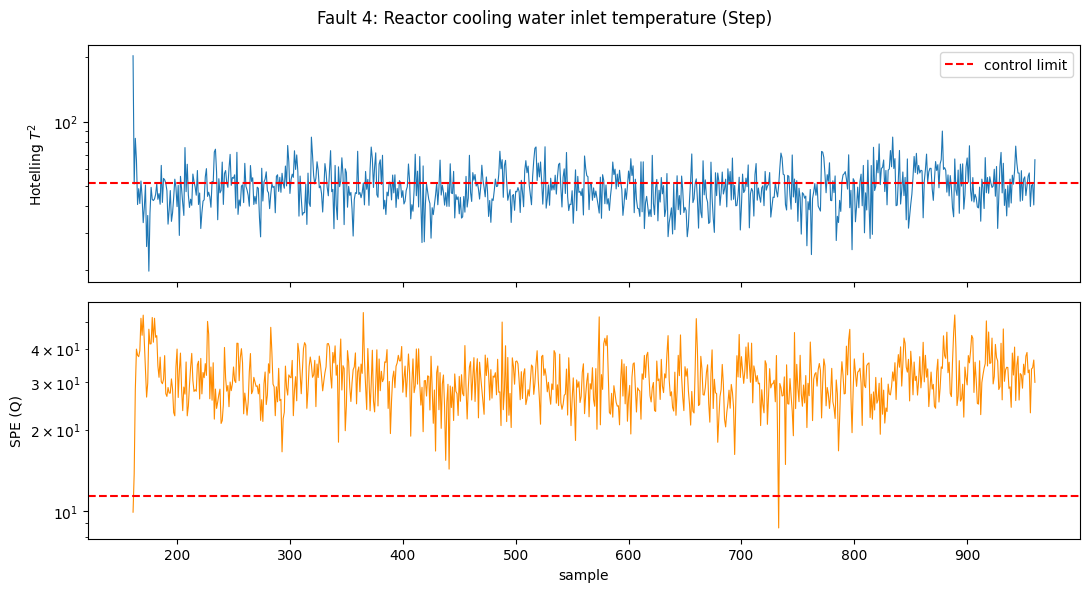

In [11]:
demo_fault = 4
gr = test_f[(test_f["faultNumber"] == demo_fault) &
            (test_f["simulationRun"] == test_f["simulationRun"].min())].sort_values("sample")
_, t2v, spev = is_anomaly(gr[FEATURES].values)

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(gr["sample"].values, t2v, lw=.8)
ax[0].axhline(T2_LIM, c="r", ls="--", label="control limit")
ax[0].set_ylabel("Hotelling $T^2$"); ax[0].set_yscale("log"); ax[0].legend()
ax[1].plot(gr["sample"].values, spev, lw=.8, c="darkorange")
ax[1].axhline(SPE_LIM, c="r", ls="--")
ax[1].set_ylabel("SPE (Q)"); ax[1].set_yscale("log"); ax[1].set_xlabel("sample")
fig.suptitle(f"Fault {demo_fault}: {FAULT_DICT[demo_fault]}", y=.98)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/t2_spe_demo.png", dpi=120); plt.show()

---
## 5. Layer 2 — Fault classification

Runs **after** an anomaly is flagged. Trained on Training files, tested on Testing files —
separate simulation runs.

**LightGBM, no hyperparameter tuning.** The goal is an honest fast number, not a high one.

> **Why not RandomForest?** `min_samples_leaf=2` with no `max_depth` on ~380k rows grows trees
> with tens of thousands of leaves and depth 40-50. `TreeExplainer` costs roughly
> **O(trees × leaves × depth²)** per row, so SHAP on such a forest does not finish.
> Bounding the model at 31 leaves / depth 8 keeps the accuracy honest and brings SHAP
> down to seconds.


In [12]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import lightgbm as lgb

Xtr, ytr = train_f[FEATURES].values, train_f["faultNumber"].values
Xte, yte = test_f[FEATURES].values,  test_f["faultNumber"].values
print(f"train: {Xtr.shape}   test: {Xte.shape}")

MODEL_NAME = "LightGBM · 200 trees · 31 leaves · depth 8 · no tuning"

t0 = time.time()
clf = lgb.LGBMClassifier(
    n_estimators=200,
    num_leaves=31,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.8, subsample_freq=1,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1,
).fit(Xtr, ytr)
print(f"trained in {time.time()-t0:.0f}s")

# --- RandomForest fallback, if you want it -- note the depth caps, they are what
# --- keeps SHAP tractable. Do NOT remove them.
# from sklearn.ensemble import RandomForestClassifier
# clf = RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=50,
#                              n_jobs=-1, random_state=RANDOM_STATE).fit(Xtr, ytr)

pred = clf.predict(Xte)
acc = accuracy_score(yte, pred)
f1m = f1_score(yte, pred, average="macro")
print(f"\nModel    = {MODEL_NAME}")
print(f"Accuracy = {acc:.4f}")
print(f"Macro F1 = {f1m:.4f}")


train: (384000, 52)   test: (640000, 52)
trained in 330s


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Model    = LightGBM · 200 trees · 31 leaves · depth 8 · no tuning
Accuracy = 0.8353
Macro F1 = 0.8416


In [13]:
rep = classification_report(yte, pred, output_dict=True, zero_division=0)
per = pd.DataFrame(rep).T
per = per[per.index.str.isdigit()]
per.index = per.index.astype(int)
per["description"] = [FAULT_DICT.get(i, "?") for i in per.index]
print(per[["precision", "recall", "f1-score", "support", "description"]]
      .sort_values("f1-score").to_string(float_format=lambda x: f"{x:.3f}"))

    precision  recall  f1-score   support                                                   description
9       0.286   0.285     0.286 32000.000                         D Feed temperature (Random variation)
15      0.285   0.304     0.294 32000.000                      Condenser cooling water valve (Sticking)
3       0.333   0.474     0.391 32000.000                                     D Feed temperature (Step)
10      0.834   0.816     0.825 32000.000                         C Feed temperature (Random variation)
16      0.959   0.789     0.866 32000.000                                    Unknown (Random variation)
11      0.900   0.851     0.875 32000.000    Reactor cooling water inlet temperature (Random variation)
20      0.909   0.844     0.875 32000.000                                    Unknown (Random variation)
12      0.903   0.858     0.880 32000.000  Condenser cooling water inlet temperature (Random variation)
19      0.888   0.912     0.900 32000.000                       

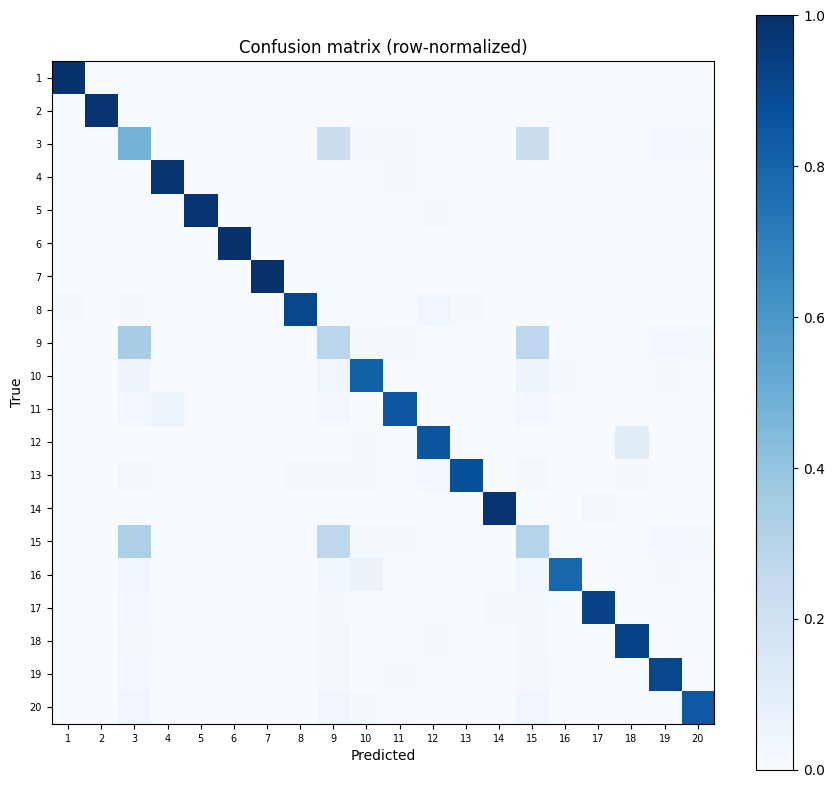


Most confused pairs (>10%):
   9 -> 3   35.0%   | D Feed temperature (Random variation)  vs D Feed temperature (Step)
  15 -> 3   32.8%   | Condenser cooling water valve (Stickin vs D Feed temperature (Step)
  15 -> 9   27.7%   | Condenser cooling water valve (Stickin vs D Feed temperature (Random variation)
   9 -> 15  27.7%   | D Feed temperature (Random variation)  vs Condenser cooling water valve (Stickin
   3 -> 15  22.5%   | D Feed temperature (Step)              vs Condenser cooling water valve (Stickin
   3 -> 9   21.9%   | D Feed temperature (Step)              vs D Feed temperature (Random variation)
  12 -> 18  11.0%   | Condenser cooling water inlet temperat vs Unknown (Step)


In [14]:
cm = confusion_matrix(yte, pred, normalize="true")
labels = sorted(np.unique(yte))

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=7)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix (row-normalized)")
plt.colorbar(im); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion.png", dpi=120); plt.show()

cm2 = cm.copy(); np.fill_diagonal(cm2, 0)
pairs = [(labels[i], labels[j], cm2[i, j])
         for i in range(len(labels)) for j in range(len(labels)) if cm2[i, j] > .10]
pairs.sort(key=lambda x: -x[2])
print("\nMost confused pairs (>10%):")
for a, b, v in pairs[:10]:
    print(f"  {a:>2} -> {b:<2}  {v:.1%}   | {FAULT_DICT.get(a,'')[:38]:38s} vs {FAULT_DICT.get(b,'')[:38]}")

---
## 6. SHAP — from contributing variables to physical mechanism

The chain that makes this work different:

> anomaly → contributing variables → **candidate physical mechanism**

The model says *"reactor pressure and cooling water temperature are the drivers"*.
The engineer completes it: *"that is the signature of a cooling circuit fault."*

In [15]:
!pip install -q shap lightgbm


In [16]:
import shap

VAR_NAMES = {
    "xmeas_1": "A Feed", "xmeas_2": "D Feed", "xmeas_3": "E Feed", "xmeas_4": "A+C Feed",
    "xmeas_5": "Recycle Flow", "xmeas_6": "Reactor Feed Rate",
    "xmeas_7": "Reactor Pressure", "xmeas_8": "Reactor Level", "xmeas_9": "Reactor Temp",
    "xmeas_10": "Purge Rate", "xmeas_11": "Separator Temp", "xmeas_12": "Separator Level",
    "xmeas_13": "Separator Pressure", "xmeas_14": "Separator Underflow",
    "xmeas_15": "Stripper Level", "xmeas_16": "Stripper Pressure",
    "xmeas_17": "Stripper Underflow", "xmeas_18": "Stripper Temp",
    "xmeas_19": "Stripper Steam Flow", "xmeas_20": "Compressor Work",
    "xmeas_21": "Reactor CW Outlet Temp", "xmeas_22": "Condenser CW Outlet Temp",
    "xmv_3": "A Feed Valve", "xmv_6": "Purge Valve",
    "xmv_10": "Reactor CW Valve", "xmv_11": "Condenser CW Valve",
}
nice = [VAR_NAMES.get(c, c) for c in FEATURES]

samp = test_f.sample(n=min(SHAP_N, len(test_f)), random_state=RANDOM_STATE)

t0 = time.time()
expl = shap.TreeExplainer(clf)
sv = expl.shap_values(samp[FEATURES].values, check_additivity=False)

# --- Shape normalisation across shap versions. This matters. ---
# Newer shap returns an ndarray (n, n_features, n_classes).
# Older shap returns a LIST of n_classes arrays, each (n, n_features).
# np.array() on that list gives (n_classes, n, n_features) -- which ALSO has ndim == 3,
# so a naive `if v.ndim == 3` test passes and then indexes the FEATURE axis as if it
# were the class axis. Wrong numbers, or an IndexError far from the real cause.
if isinstance(sv, list):
    sv = np.stack(sv, axis=-1)
sv = np.asarray(sv)
assert sv.shape == (len(samp), len(FEATURES), len(clf.classes_)), \
    f"unexpected shap shape {sv.shape}, expected {(len(samp), len(FEATURES), len(clf.classes_))}"

print(f"shap values ready in {time.time()-t0:.0f}s   shape={sv.shape}  (rows, features, classes)")


shap values ready in 51s   shape=(800, 52, 20)  (rows, features, classes)


In [17]:
CLASSES = list(clf.classes_)

def top_drivers(fault_id, n=8):
    """Variables contributing most to predicting a given fault (mean |SHAP|)."""
    if fault_id not in CLASSES:
        return None
    contrib = sv[:, :, CLASSES.index(fault_id)]          # (rows, features)
    mask = (samp["faultNumber"].values == fault_id)
    if mask.sum() == 0:
        return None
    imp = np.abs(contrib[mask]).mean(axis=0)
    order = np.argsort(imp)[::-1][:n]
    return pd.DataFrame({"variable": [nice[i] for i in order],
                         "mean_abs_shap": imp[order]})

for f in [4, 6, 13, 14]:
    d = top_drivers(f)
    if d is None:
        continue
    print("=" * 74)
    print(f"Fault {f}: {FAULT_DICT[f]}")
    print(f"Expected mechanism: {FAULT_MECHANISM.get(f, '-')}")
    print("-" * 74)
    print(d.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print()


Fault 4: Reactor cooling water inlet temperature (Step)
Expected mechanism: Reactor cooling water inlet temp step -> reactor temp rises, CW valve opens
--------------------------------------------------------------------------
              variable  mean_abs_shap
      Reactor CW Valve         9.8446
Reactor CW Outlet Temp         0.9290
          Reactor Temp         0.6648
         Stripper Temp         0.6035
                 xmv_5         0.1533
                 xmv_9         0.1413
   Stripper Steam Flow         0.1064
       Compressor Work         0.1045

Fault 6: A Feed loss (Step)
Expected mechanism: A feed loss -> sharp drop in pressure and conversion
--------------------------------------------------------------------------
              variable  mean_abs_shap
                A Feed        19.6853
          A Feed Valve         6.3634
              xmeas_25         1.5233
              xmeas_23         1.1544
              xmeas_29         0.9660
              A+C Feed    

---
## 6b. Cross-check — SHAP vs. SPE contribution plots

Layer 1 is a PCA model, and multivariate process monitoring already has a native answer to
*"which variable drove this deviation"*: the **contribution plot**. For the Q statistic it is
the squared residual of each variable after projection onto the PCA model —
closed-form, exact, and essentially free (one matrix multiply).

Two independent attributions of the same event:

| | SHAP | SPE contribution |
|---|---|---|
| Source | Layer 2 classifier | Layer 1 PCA detector |
| Supervision | needs fault labels | **unsupervised — normal data only** |
| Nature | game-theoretic approximation | exact, closed form |
| Cost | seconds to minutes | milliseconds |

**Where they agree**, the attribution is robust. **Where they disagree** is the interesting part,
and the honest reading is that the classifier may have latched onto a label-correlated variable
that carries no physical role in the mechanism. Report the disagreements — do not hide them.


In [18]:
def spe_contributions(X):
    """Per-variable contribution to SPE (Q). Closed form, no approximation."""
    Xs = scaler.transform(X)
    Xr = pca.inverse_transform(pca.transform(Xs))
    return (Xs - Xr) ** 2                                # (rows, features)


def spe_drivers(fault_id, n=8, max_rows=20_000):
    """Top SPE contributors, computed on the ALARMED windows only."""
    sub = test_f[test_f["faultNumber"] == fault_id]
    if len(sub) == 0:
        return None
    if len(sub) > max_rows:
        sub = sub.sample(max_rows, random_state=RANDOM_STATE)
    X = sub[FEATURES].values
    flag, _, _ = is_anomaly(X)
    if flag.sum() == 0:
        return None
    c = spe_contributions(X[flag]).mean(axis=0)
    order = np.argsort(c)[::-1][:n]
    return pd.DataFrame({"variable": [nice[i] for i in order],
                         "spe_contribution": c[order]})


TOPK = 6
agreement = {}

for f in [4, 6, 13, 14]:
    a = top_drivers(f, n=TOPK)
    b = spe_drivers(f, n=TOPK)
    if a is None or b is None:
        continue
    sa, sb = list(a["variable"]), list(b["variable"])
    shared = [v for v in sa if v in sb]
    agreement[int(f)] = len(shared)

    print("=" * 78)
    print(f"Fault {f}: {FAULT_DICT[f]}")
    print(f"Expected mechanism: {FAULT_MECHANISM.get(f, '-')}")
    print("-" * 78)
    print(f"{'rank':<5}{'SHAP (classifier)':<32}{'SPE contribution (detector)':<32}")
    for i in range(TOPK):
        m1 = "*" if sa[i] in sb else " "
        m2 = "*" if sb[i] in sa else " "
        print(f"{i+1:<5}{m1 + ' ' + sa[i]:<32}{m2 + ' ' + sb[i]:<32}")
    print("-" * 78)
    print(f"agreement in top-{TOPK}: {len(shared)}/{TOPK}   (* = appears in both)")
    print(f"SHAP only : {[v for v in sa if v not in sb]}")
    print(f"SPE  only : {[v for v in sb if v not in sa]}")
    print()

print("=" * 78)
print("Agreement summary (write this into docs/VALIDATION.md):")
for f, v in agreement.items():
    verdict = "robust" if v >= 4 else ("partial" if v >= 2 else "DISAGREES - investigate")
    print(f"  fault {f:>2}: {v}/{TOPK}  {verdict}")


Fault 4: Reactor cooling water inlet temperature (Step)
Expected mechanism: Reactor cooling water inlet temp step -> reactor temp rises, CW valve opens
------------------------------------------------------------------------------
rank SHAP (classifier)               SPE contribution (detector)     
1    * Reactor CW Valve              * Reactor CW Valve              
2      Reactor CW Outlet Temp        * Reactor Temp                  
3    * Reactor Temp                    xmeas_25                      
4      Stripper Temp                   D Feed                        
5      xmv_5                           xmeas_33                      
6      xmv_9                           xmeas_29                      
------------------------------------------------------------------------------
agreement in top-6: 2/6   (* = appears in both)
SHAP only : ['Reactor CW Outlet Temp', 'Stripper Temp', 'xmv_5', 'xmv_9']
SPE  only : ['xmeas_25', 'D Feed', 'xmeas_33', 'xmeas_29']

Fault 6: A Feed lo

### Engineering validation — fill this in yourself

For each fault above, answer:

| Question | Why it matters |
|---|---|
| Are the SHAP-highlighted variables **physically consistent** with the fault mechanism? | If not, the model learned a correlation, not a cause |
| Which faults does the model confuse? Are they **physically similar**? | Confusing 3 and 9 (both D Feed temperature) is acceptable; confusing a feed fault with a cooling fault is not |
| Which faults have low detection rates, and why? | Faults 3, 9 and 15 are known to be hard to detect in the literature — compare your result to that |

> Write the answers in `docs/VALIDATION.md`. **This is the document that gets read in an interview.**

---
## 7. Save results

In [19]:
results = {
    "config": {
        "n_runs_train": N_RUNS_TRAIN,
        "n_runs_test": N_RUNS_TEST,
        "n_features": len(FEATURES),
        "pca_components": int(k),
    },
    "anomaly_detection": {
        "false_alarm_rate": float(FAR),
        "t2_limit": float(T2_LIM),
        "spe_limit": float(SPE_LIM),
        "detection_rate_by_fault": det.set_index("fault")["detection_rate"].round(4).to_dict(),
    },
    "classification": {
        "model": MODEL_NAME,
        "accuracy": float(acc),
        "macro_f1": float(f1m),
        "n_train": int(len(Xtr)),
        "n_test": int(len(Xte)),
        "split": "Training files vs Testing files - separate simulation runs, no leakage",
    },
    "attribution_cross_check": {
        "method": "SHAP (classifier) vs SPE contribution plots (PCA detector)",
        "top_k": TOPK,
        "agreement_by_fault": agreement,
    },
}

with open(f"{OUT_DIR}/results.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results["classification"], indent=2))
print(f"\nFAR: {FAR:.2%}")
print(f"saved -> {OUT_DIR}/results.json")

{
  "model": "LightGBM \u00b7 200 trees \u00b7 31 leaves \u00b7 depth 8 \u00b7 no tuning",
  "accuracy": 0.8353328125,
  "macro_f1": 0.841554683767497,
  "n_train": 384000,
  "n_test": 640000,
  "split": "Training files vs Testing files - separate simulation runs, no leakage"
}

FAR: 2.11%
saved -> /content/tep_out/results.json


---

## Summary

**What to write in the README:**

> The results below use a correct split: training from the Training files and testing from the
> Testing files, which are entirely separate simulation runs. The very high accuracies commonly
> reported on this dataset come from random row-level splitting, which leaks temporally correlated
> samples between train and test and does not generalise.

**Next step:** fill in `docs/VALIDATION.md` with the engineering validation answers above.

**Also write down:**

> Attribution was cross-checked two ways: SHAP on the supervised classifier, and SPE
> contribution plots on the unsupervised PCA detector. Agreement in the top-6 variables is
> reported per fault. Faults where the two disagree are flagged rather than smoothed over.

**Next step:** fill in `docs/VALIDATION.md` with the engineering validation answers above.


---

# Part 2 — Physics-Informed Residuals & Temporal Features

## The hypothesis being tested

Part 1 found that faults **3, 9 and 15** are undetectable — detection rate equals the false
alarm rate, meaning zero signal.

A closer look at the TEP measurement set shows **why**, and it is sharper than "the controller
compensates":

| Fault | Disturbed variable | Measured? |
|:---:|---|:---:|
| 3 | D feed **temperature** | ❌ not in the 22 measurements |
| 9 | D feed **temperature** | ❌ |
| 15 | **Actual position** of condenser CW valve | ❌ — only the *command* `xmv_11` is measured |

This is an **observability** problem, not a sensitivity problem.

> **Precise statement:** a fault is undetectable when the disturbed variable is **unmeasured**
> *and* its post-compensation effect is **smaller than normal operating variability**.
> Both conditions together.

Faults 4 and 11 are also in unmeasured cooling water temperature — but they *are* detected
(100% and 78%), because their thermal effect on the reactor is large enough to force a visible
compensating action.

### What physics-informed residuals do about it

A residual reconstructs an **unmeasured quantity** from measured ones using a known physical
relationship:

- **Reactor energy balance** — heat removed should track the cooling action. If D feed enters
  hotter, more cooling is needed for the same conversion. The *individual* variables all stay
  inside their limits; the **residual aggregates the effect into one quantity**.
- **Condenser duty** — separator temperature should track the *commanded* CW valve. A sticking
  valve breaks that relationship, which is exactly the signature of fault 15.

**Structure comes from physics; coefficients are fitted on normal data.**
This is hybrid semi-parametric modelling — not a PINN, and honestly labelled as such.

> **A negative result is also a result.** If the residuals do not surface faults 3, 9 and 15,
> that establishes a physical detection limit you can state with confidence.

In [20]:
# Additional imports for Part 2
from sklearn.linear_model import Ridge
import lightgbm as lgb
print("Part 2 ready.")

Part 2 ready.


---
## 8. Physics-informed residual definitions

Each residual is `actual - predicted`, where the predictor is a linear relation whose
**inputs are chosen by process physics** and whose coefficients are fitted on **normal
operating data only**.

| Residual | Target | Physical inputs | Targets fault |
|---|---|---|---|
| `r_reactor_energy` | Reactor temperature | CW flow, CW outlet temp, feed rate, pressure | 3, 9 (feed enthalpy) |
| `r_condenser_duty` | Separator temperature | CW flow command, CW outlet temp, sep pressure | **15** (valve sticking) |
| `r_reactor_pressure` | Reactor pressure | feed rate, temperature, level | feed / conversion upsets |
| `r_compressor` | Compressor work | recycle flow, reactor & separator pressure | recycle path |
| `r_stripper` | Stripper temperature | steam flow, underflow, sep underflow | stripping duty |
| `r_mass_balance` | Product + purge | all four feeds | feed loss / leaks |

In [21]:
# TEP variable map (Downs & Vogel, 1993)
V = {
    "A_feed": "xmeas_1", "D_feed": "xmeas_2", "E_feed": "xmeas_3", "AC_feed": "xmeas_4",
    "recycle": "xmeas_5", "rx_feed_rate": "xmeas_6",
    "rx_press": "xmeas_7", "rx_level": "xmeas_8", "rx_temp": "xmeas_9",
    "purge": "xmeas_10",
    "sep_temp": "xmeas_11", "sep_level": "xmeas_12", "sep_press": "xmeas_13",
    "sep_underflow": "xmeas_14",
    "str_level": "xmeas_15", "str_press": "xmeas_16", "str_underflow": "xmeas_17",
    "str_temp": "xmeas_18", "str_steam": "xmeas_19",
    "comp_work": "xmeas_20",
    "rx_cw_out": "xmeas_21", "cond_cw_out": "xmeas_22",
    "v_D": "xmv_1", "v_E": "xmv_2", "v_A": "xmv_3", "v_AC": "xmv_4",
    "v_recycle": "xmv_5", "v_purge": "xmv_6", "v_sep": "xmv_7", "v_prod": "xmv_8",
    "v_steam": "xmv_9", "v_rx_cw": "xmv_10", "v_cond_cw": "xmv_11",
}

RESIDUALS = {
    # reactor energy balance: heat removal must track the cooling action
    "r_reactor_energy": {
        "target": V["rx_temp"],
        "inputs": [V["v_rx_cw"], V["rx_cw_out"], V["rx_feed_rate"], V["rx_press"]],
    },
    # condenser duty: separator temperature vs COMMANDED valve
    # a sticking valve breaks this relation -> targets fault 15
    "r_condenser_duty": {
        "target": V["sep_temp"],
        "inputs": [V["v_cond_cw"], V["cond_cw_out"], V["sep_press"]],
    },
    "r_reactor_pressure": {
        "target": V["rx_press"],
        "inputs": [V["rx_feed_rate"], V["rx_temp"], V["rx_level"], V["purge"]],
    },
    "r_compressor": {
        "target": V["comp_work"],
        "inputs": [V["recycle"], V["rx_press"], V["sep_press"], V["v_recycle"]],
    },
    "r_stripper": {
        "target": V["str_temp"],
        "inputs": [V["str_steam"], V["str_underflow"], V["sep_underflow"], V["str_press"]],
    },
    "r_mass_balance": {
        "target": V["str_underflow"],
        "inputs": [V["A_feed"], V["D_feed"], V["E_feed"], V["AC_feed"], V["purge"]],
    },
}

missing = []
for name, spec in RESIDUALS.items():
    for c in [spec["target"]] + spec["inputs"]:
        if c not in FEATURES:
            missing.append((name, c))
print("missing columns:", missing if missing else "none")
print(f"{len(RESIDUALS)} residuals defined")

missing columns: none
6 residuals defined


In [22]:
# Fit each relation on NORMAL TRAINING DATA ONLY
residual_models = {}
for name, spec in RESIDUALS.items():
    Xi = train_ff[spec["inputs"]].values
    yi = train_ff[spec["target"]].values
    m = Ridge(alpha=1.0).fit(Xi, yi)
    pred = m.predict(Xi)
    rmse = float(np.sqrt(np.mean((yi - pred) ** 2)))
    r2 = float(m.score(Xi, yi))
    residual_models[name] = m
    print(f"{name:22s} R2={r2:6.3f}  RMSE={rmse:8.4f}  ({spec['target']} <- {len(spec['inputs'])} inputs)")

print()
print("Note: a HIGH R2 on normal data means the physical relation holds and the residual")
print("is a clean monitoring signal. A LOW R2 means the chosen inputs do not explain the")
print("target - that residual will be noisy and weak.")

r_reactor_energy       R2= 0.398  RMSE=  0.0149  (xmeas_9 <- 4 inputs)
r_condenser_duty       R2= 0.606  RMSE=  0.1562  (xmeas_11 <- 3 inputs)
r_reactor_pressure     R2= 0.099  RMSE=  7.5867  (xmeas_7 <- 4 inputs)
r_compressor           R2= 0.851  RMSE=  0.6927  (xmeas_20 <- 4 inputs)
r_stripper             R2= 0.941  RMSE=  0.1075  (xmeas_18 <- 4 inputs)
r_mass_balance         R2= 0.001  RMSE=  0.6151  (xmeas_17 <- 5 inputs)

Note: a HIGH R2 on normal data means the physical relation holds and the residual
is a clean monitoring signal. A LOW R2 means the chosen inputs do not explain the
target - that residual will be noisy and weak.


In [23]:
def add_residuals(df):
    """Append physics residuals as new columns."""
    out = df.copy()
    for name, spec in RESIDUALS.items():
        pred = residual_models[name].predict(df[spec["inputs"]].values)
        out[name] = (df[spec["target"]].values - pred).astype(np.float32)
    return out

t0 = time.time()
train_ff_r = add_residuals(train_ff)
train_f_r  = add_residuals(train_f)
test_ff_r  = add_residuals(test_ff)
test_f_r   = add_residuals(test_f)
RES_COLS = list(RESIDUALS.keys())
print(f"residuals computed in {time.time()-t0:.0f}s")
print("residual columns:", RES_COLS)

residuals computed in 1s
residual columns: ['r_reactor_energy', 'r_condenser_duty', 'r_reactor_pressure', 'r_compressor', 'r_stripper', 'r_mass_balance']


---
## 9. Temporal features

Faults 3 and 9 disturb the **same variable** (D feed temperature). One is a **step**, the other
a **random variation**. The difference is purely temporal — and a sample-level model cannot
see it at all.

Rolling statistics make the distinction available:

- **step** → jump then settle → *low* rolling std after the jump
- **random** → continuous fluctuation → *high* rolling std throughout

> ⚠️ Windows are computed **inside each `simulationRun` separately**. Crossing run boundaries
> would mix the end of one simulation with the start of another — a new form of leakage.

In [24]:
WINDOW = 30          # samples (30 x 3 min = 1.5 hours)
TEMPORAL_BASE = [
    V["rx_temp"], V["rx_press"], V["sep_temp"], V["str_temp"],
    V["rx_cw_out"], V["cond_cw_out"], V["v_rx_cw"], V["v_cond_cw"],
    V["A_feed"], V["D_feed"], V["purge"], V["comp_work"],
] + RES_COLS   # residuals get temporal features too

def add_temporal(df, cols=TEMPORAL_BASE, w=WINDOW):
    """Rolling mean / std / range, computed WITHIN each simulationRun."""
    out = df.sort_values(["faultNumber", "simulationRun", "sample"]).copy()
    g = out.groupby(["faultNumber", "simulationRun"], sort=False)[cols]
    roll = g.rolling(w, min_periods=5)

    mean = roll.mean().reset_index(level=[0, 1], drop=True)
    std  = roll.std().reset_index(level=[0, 1], drop=True)
    mx   = roll.max().reset_index(level=[0, 1], drop=True)
    mn   = roll.min().reset_index(level=[0, 1], drop=True)

    for c in cols:
        out[f"{c}_mean"]  = mean[c].astype(np.float32)
        out[f"{c}_std"]   = std[c].astype(np.float32)
        out[f"{c}_range"] = (mx[c] - mn[c]).astype(np.float32)
    return out.dropna().reset_index(drop=True)

t0 = time.time()
train_ff_t = add_temporal(train_ff_r)
train_f_t  = add_temporal(train_f_r)
test_ff_t  = add_temporal(test_ff_r)
test_f_t   = add_temporal(test_f_r)
print(f"temporal features in {time.time()-t0:.0f}s")

TEMP_COLS = [f"{c}_{s}" for c in TEMPORAL_BASE for s in ("mean", "std", "range")]
print(f"raw={len(FEATURES)}  residual={len(RES_COLS)}  temporal={len(TEMP_COLS)}")
print(f"rows after dropna: train_f {len(train_f_t):,}  test_f {len(test_f_t):,}")

temporal features in 20s
raw=52  residual=6  temporal=54
rows after dropna: train_f 380,800  test_f 636,800


---
## 10. Compare four detectors

Same PCA / T² / SPE machinery, four different feature sets. Control limits are always fitted
on **normal training data only**.

| Set | Features |
|---|---|
| **A — raw** | 52 process variables (Part 1 baseline) |
| **B — residuals only** | 6 physics residuals |
| **C — raw + residuals** | 58 |
| **D — all + temporal** | raw + residuals + rolling statistics |

In [25]:
def build_detector(train_normal, cols, var=0.90, pct=99.0):
    sc = StandardScaler().fit(train_normal[cols].values)
    Xn = sc.transform(train_normal[cols].values)
    p  = PCA(n_components=var, random_state=RANDOM_STATE).fit(Xn)

    def stats(X):
        Xs = sc.transform(X)
        T  = p.transform(Xs)
        t2 = np.sum(T**2 / p.explained_variance_, axis=1)
        Xr = p.inverse_transform(T)
        spe = np.sum((Xs - Xr)**2, axis=1)
        return t2, spe

    t2_tr, spe_tr = stats(train_normal[cols].values)
    lim = (np.percentile(t2_tr, pct), np.percentile(spe_tr, pct))

    def flag(df):
        t2, spe = stats(df[cols].values)
        return (t2 > lim[0]) | (spe > lim[1])

    return {"flag": flag, "k": p.n_components_, "cols": cols}


SETS = {
    "A_raw":            (train_ff,   test_ff,   test_f,   FEATURES),
    "B_residuals":      (train_ff_r, test_ff_r, test_f_r, RES_COLS),
    "C_raw+resid":      (train_ff_r, test_ff_r, test_f_r, FEATURES + RES_COLS),
    "D_all+temporal":   (train_ff_t, test_ff_t, test_f_t, FEATURES + RES_COLS + TEMP_COLS),
}

detectors, summary = {}, []
for name, (tr, te_ff, te_f, cols) in SETS.items():
    d = build_detector(tr, cols)
    far = d["flag"](te_ff).mean()
    detectors[name] = {"det": d, "test_ff": te_ff, "test_f": te_f}
    summary.append({"set": name, "n_features": len(cols), "pca_k": d["k"], "FAR": far})
    print(f"{name:16s} features={len(cols):>4}  PCA k={d['k']:>3}  FAR={far:.2%}")

pd.DataFrame(summary)

A_raw            features=  52  PCA k= 31  FAR=2.11%
B_residuals      features=   6  PCA k=  5  FAR=2.16%
C_raw+resid      features=  58  PCA k= 32  FAR=2.19%
D_all+temporal   features= 112  PCA k= 50  FAR=1.42%


,set,n_features,pca_k,FAR
0,A_raw,52,31,0.021094
1,B_residuals,6,5,0.021562
2,C_raw+resid,58,32,0.021906
3,D_all+temporal,112,50,0.014165


In [26]:
# Detection rate per fault, all four detectors
rows = []
faults = sorted(test_f["faultNumber"].unique())

for f in faults:
    r = {"fault": int(f), "description": FAULT_DICT.get(int(f), "?")[:46]}
    for name, obj in detectors.items():
        sub = obj["test_f"]
        sub = sub[sub["faultNumber"] == f]
        r[name] = obj["det"]["flag"](sub).mean() if len(sub) else np.nan
    rows.append(r)

det_cmp = pd.DataFrame(rows)
far_row = {"fault": "FAR", "description": "(false alarm rate on normal)"}
for name, obj in detectors.items():
    far_row[name] = obj["det"]["flag"](obj["test_ff"]).mean()

show = pd.concat([pd.DataFrame([far_row]), det_cmp.sort_values("A_raw")], ignore_index=True)
print(show.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

fault                                    description  A_raw  B_residuals  C_raw+resid  D_all+temporal
  FAR                   (false alarm rate on normal)  0.021        0.022        0.022           0.014
    3                      D Feed temperature (Step)  0.021        0.021        0.023           0.015
    9          D Feed temperature (Random variation)  0.022        0.022        0.023           0.015
   15       Condenser cooling water valve (Sticking)  0.024        0.031        0.026           0.021
   19                     Unknown (Random variation)  0.174        0.613        0.667           1.000
   16                     Unknown (Random variation)  0.271        0.328        0.373           0.786
    5 Condenser cooling water inlet temperature (Ste  0.272        0.234        0.280           1.000
   10          C Feed temperature (Random variation)  0.406        0.845        0.797           0.976
   20                     Unknown (Random variation)  0.548        0.661        0.

### ⭐ The result that matters

Look at faults **3, 9, 15** across the four columns, and compare each to that column's FAR.

| Outcome | Meaning |
|---|---|
| Detection rate **rises clearly above FAR** | The residual reconstructed the unmeasured quantity. Hypothesis confirmed. |
| Detection rate **stays at FAR** | The disturbance is genuinely below the noise floor of the balance itself — a **physical detection limit**, not a modelling gap. State it as such. |

Also check whether **FAR rose** in the richer sets. More features means a looser normal model:
a detector that gains 5 points of detection while doubling false alarms has not improved.

In [27]:
# Focused view: the three previously-undetectable faults
focus = show[show["fault"].isin(["FAR", 3, 9, 15])]
print("THE KEY COMPARISON\n")
print(focus.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\n" + "="*70)
base_far = far_row["A_raw"]
for f in [3, 9, 15]:
    row = det_cmp[det_cmp["fault"] == f].iloc[0]
    best_set = max(detectors, key=lambda n: row[n])
    best_val = row[best_set]
    best_far = far_row[best_set]
    lift = best_val / best_far if best_far > 0 else np.nan
    verdict = "SIGNAL FOUND" if lift > 2.0 else "still at noise floor"
    print(f"fault {f:>2}: best={best_set:16s} rate={best_val:.3f}  "
          f"FAR={best_far:.3f}  ratio={lift:4.1f}x  -> {verdict}")

THE KEY COMPARISON

fault                              description  A_raw  B_residuals  C_raw+resid  D_all+temporal
  FAR             (false alarm rate on normal)  0.021        0.022        0.022           0.014
    3                D Feed temperature (Step)  0.021        0.021        0.023           0.015
    9    D Feed temperature (Random variation)  0.022        0.022        0.023           0.015
   15 Condenser cooling water valve (Sticking)  0.024        0.031        0.026           0.021

fault  3: best=C_raw+resid      rate=0.023  FAR=0.022  ratio= 1.0x  -> still at noise floor
fault  9: best=C_raw+resid      rate=0.023  FAR=0.022  ratio= 1.1x  -> still at noise floor
fault 15: best=B_residuals      rate=0.031  FAR=0.022  ratio= 1.4x  -> still at noise floor


---
## 11. Classifier with the enriched feature set

Does adding residuals and temporal features separate faults 3 / 9 / 15 from each other?

In [28]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

FULL = FEATURES + RES_COLS + TEMP_COLS
Xtr, ytr = train_f_t[FULL].values, train_f_t["faultNumber"].values
Xte, yte = test_f_t[FULL].values,  test_f_t["faultNumber"].values
print(f"train {Xtr.shape}  test {Xte.shape}")

t0 = time.time()
clf2 = lgb.LGBMClassifier(n_estimators=200, num_leaves=31, max_depth=8,
                          n_jobs=-1, random_state=RANDOM_STATE, verbose=-1).fit(Xtr, ytr)
print(f"trained in {time.time()-t0:.0f}s")

pred2 = clf2.predict(Xte)
acc2 = accuracy_score(yte, pred2)
f1_2 = f1_score(yte, pred2, average="macro")

print(f"\n{'':22s} {'accuracy':>10s} {'macro F1':>10s}")
print(f"{'Part 1 (raw only)':22s} {0.8353:>10.4f} {0.8416:>10.4f}")
print(f"{'Part 2 (enriched)':22s} {acc2:>10.4f} {f1_2:>10.4f}")
print(f"{'delta':22s} {acc2-0.8353:>+10.4f} {f1_2-0.8416:>+10.4f}")

train (380800, 112)  test (636800, 112)
trained in 773s


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



                         accuracy   macro F1
Part 1 (raw only)          0.8353     0.8416
Part 2 (enriched)          0.9092     0.9117
delta                     +0.0739    +0.0701


In [29]:
# Did the 3 / 9 / 15 cluster separate?
cm = confusion_matrix(yte, pred2, normalize="true")
labels = sorted(np.unique(yte))
idx = {l: i for i, l in enumerate(labels)}

print("Recall for the previously-inseparable cluster:\n")
print(f"{'fault':>6} {'Part 1':>9} {'Part 2':>9}")
part1 = {3: 0.30, 9: 0.28, 15: 0.25}   # approximate, from the Part 1 confusion matrix
for f in [3, 9, 15]:
    if f in idx:
        print(f"{f:>6} {part1[f]:>9.2f} {cm[idx[f], idx[f]]:>9.2f}")

print("\nRemaining confusion inside the cluster:")
for a in [3, 9, 15]:
    for b in [3, 9, 15]:
        if a != b and a in idx and b in idx and cm[idx[a], idx[b]] > 0.05:
            print(f"  {a} -> {b}: {cm[idx[a], idx[b]]:.1%}")

Recall for the previously-inseparable cluster:

 fault    Part 1    Part 2
     3      0.30      0.71
     9      0.28      0.45
    15      0.25      0.59

Remaining confusion inside the cluster:
  3 -> 9: 13.5%
  3 -> 15: 14.4%
  9 -> 3: 23.2%
  9 -> 15: 31.3%
  15 -> 3: 10.8%
  15 -> 9: 29.4%


---
## 12. Save and interpret

In [31]:
import os, json
import numpy as np

def clean(o):
    if isinstance(o, dict):  return {str(k): clean(v) for k, v in o.items()}
    if isinstance(o, list):  return [clean(v) for v in o]
    if isinstance(o, (np.integer,)):  return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    return o

out = {
    "detectors": summary,
    "detection_by_fault": det_cmp.to_dict(orient="records"),
    "classifier": {
        "part1": {"accuracy": 0.8353, "macro_f1": 0.8416, "features": len(FEATURES)},
        "part2": {"accuracy": float(acc2), "macro_f1": float(f1_2), "features": len(FULL)},
    },
    "config": {"window": WINDOW, "n_residuals": len(RES_COLS)},
}

OUT = globals().get("OUT_DIR", ".")
with open(os.path.join(OUT, "results_part2.json"), "w") as fh:
    json.dump(clean(out), fh, indent=2)
print("saved -> results_part2.json")

saved -> results_part2.json


### Write these answers into `docs/VALIDATION.md`

1. **Did residuals surface faults 3 / 9 / 15?**
   If yes — the physical relation reconstructed an unmeasured quantity, and the fault was
   never truly invisible, only invisible *in the raw variable space*.
   If no — you have measured a genuine detection limit. State the noise floor of the residual
   and note that the disturbance sits below it.

2. **Which residual had the highest R² on normal data?**
   That relation is the strongest physical constraint in this plant. A low R² means the
   chosen inputs do not actually determine the target — revisit the physics, not the model.

3. **Did FAR rise in the richer feature sets?**
   More features means a looser normal model. Detection gained at the cost of doubled false
   alarms is not a gain.

4. **Did temporal features separate fault 3 from fault 9?**
   These differ only in step vs random variation of the *same* variable. If rolling std split
   them, the earlier limitation ("sample-level model cannot separate them in principle") is
   now resolved and should be rewritten.

5. **What is the honest cost?**
   Feature count, training time, and how much of the gain came from physics versus from
   temporal statistics. Run set **B** (residuals only) against set **A** to separate the two
   contributions.